<a href="https://colab.research.google.com/github/athi-raj/Heart-Disease-Predictor/blob/main/Heart_Disease_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

!rm -rf /content/Heart-Disease-Predictor

!git clone https://github.com/athi-raj/Heart-Disease-Predictor.git

Cloning into 'Heart-Disease-Predictor'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 59 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 789.37 KiB | 7.24 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [20]:
# ==========================
# CELL 2 - FUNCTIONS
# ==========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --------------------------
# Load Dataset
# --------------------------

def load_data(path):

    df = pd.read_csv(path)

    print("\nDataset Loaded Successfully")
    print(f"Shape: {df.shape}")

    return df


# --------------------------
# EDA
# --------------------------

def perform_eda(df):

    numeric_cols = df.select_dtypes(include='number').columns

    print("\nDataset Info")
    print(df.info())

    print("\nMissing Values")
    print(df.isnull().sum())

    # Histograms
    df[numeric_cols].hist(
        figsize=(14,10),
        bins=20,
        color='steelblue',
        edgecolor='white'
    )

    plt.suptitle(
        'Feature Distributions',
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # Correlation Heatmap
    plt.figure(figsize=(12,8))

    mask = np.triu(
        np.ones_like(
            df[numeric_cols].corr(),
            dtype=bool
        )
    )

    sns.heatmap(
        df[numeric_cols].corr(),
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        linewidths=0.5
    )

    plt.title(
        'Feature Correlation Matrix',
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# --------------------------
# Preprocessing
# --------------------------

def preprocess_data(df):

    numeric_cols = df.select_dtypes(
        include='number'
    ).columns

    cat_cols = df.select_dtypes(
        include='object'
    ).columns

    # Missing Values

    df[numeric_cols] = df[numeric_cols].fillna(
        df[numeric_cols].median()
    )

    df[cat_cols] = df[cat_cols].fillna(
        'Unknown'
    )

    # Target

    y = (df['num'] > 0).astype(int)

    # Features

    X = df.drop(
        'num',
        axis=1
    )

    # One Hot Encoding

    X = pd.get_dummies(X)

    feature_columns = X.columns.tolist()

    # Train Test Split

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y

    )

    # SMOTE

    smote = SMOTE(
        random_state=42
    )

    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )

    # Scaling

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_resampled
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    print("\nPreprocessing Completed")
    print(f"Train Samples : {len(X_train_resampled)}")
    print(f"Test Samples  : {len(X_test)}")
    print(f"Features      : {len(feature_columns)}")

    return (

        X_train_scaled,
        X_test_scaled,

        y_train_resampled,
        y_test,

        scaler,

        feature_columns

    )


# --------------------------
# Build Model
# --------------------------

def build_model(input_shape):

    model = Sequential([

        Dense(
            128,
            activation='relu',
            input_shape=(input_shape,)
        ),

        BatchNormalization(),

        Dropout(0.3),

        Dense(
            64,
            activation='relu'
        ),

        BatchNormalization(),

        Dropout(0.2),

        Dense(
            32,
            activation='relu'
        ),

        Dense(
            1,
            activation='sigmoid'
        )

    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.0005
        ),

        loss='binary_crossentropy',

        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(
                name='auc'
            )
        ]

    )

    return model

In [14]:
# ==========================
# CELL 3 - TRAINING,
# EVALUATION & SAVE FUNCTIONS
# ==========================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# --------------------------
# Train Model
# --------------------------

def train_model(
    model,
    X_train_scaled,
    y_train_resampled
):

    callbacks = [

        EarlyStopping(
            monitor='val_auc',
            patience=15,
            restore_best_weights=True,
            mode='max'
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            verbose=1
        )
    ]

    history = model.fit(

        X_train_scaled,

        y_train_resampled,

        epochs=100,

        batch_size=32,

        validation_split=0.2,

        callbacks=callbacks,

        verbose=1

    )

    return history


# --------------------------
# Evaluate Model
# --------------------------

def evaluate_model(
    model,
    X_test_scaled,
    y_test
):

    y_pred_prob = model.predict(
        X_test_scaled
    )

    # Find Best Threshold

    best_threshold = 0.5
    best_accuracy = 0

    for t in np.arange(
        0.30,
        0.70,
        0.01
    ):

        pred = (
            y_pred_prob > t
        ).astype(int)

        acc = accuracy_score(
            y_test,
            pred
        )

        if acc > best_accuracy:

            best_accuracy = acc

            best_threshold = t

    print(
        f"\nBest Threshold: {best_threshold:.2f}"
    )

    print(
        f"Best Accuracy : {best_accuracy:.4f}"
    )

    y_pred = (
        y_pred_prob > best_threshold
    ).astype(int)

    # Metrics

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_pred_prob
    )

    print(
        "\n========== PERFORMANCE METRICS =========="
    )

    print(
        f"Accuracy   : {accuracy*100:.2f}%"
    )

    print(
        f"Precision  : {precision*100:.2f}%"
    )

    print(
        f"Recall     : {recall*100:.2f}%"
    )

    print(
        f"F1 Score   : {f1*100:.2f}%"
    )

    print(
        f"ROC-AUC    : {roc_auc:.4f}"
    )

    print(
        "========================================="
    )

    # Classification Report

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                'No Disease',
                'Disease'
            ]
        )
    )

    # Confusion Matrix

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(
        figsize=(6,5)
    )

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues',

        xticklabels=[
            'No Disease',
            'Disease'
        ],

        yticklabels=[
            'No Disease',
            'Disease'
        ]

    )

    plt.title(
        'Confusion Matrix'
    )

    plt.xlabel(
        'Predicted'
    )

    plt.ylabel(
        'Actual'
    )

    plt.show()

    # ROC Curve

    fpr, tpr, _ = roc_curve(
        y_test,
        y_pred_prob
    )

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(

        fpr,

        tpr,

        linewidth=2,

        label=f'AUC = {roc_auc:.4f}'

    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel(
        'False Positive Rate'
    )

    plt.ylabel(
        'True Positive Rate'
    )

    plt.title(
        'ROC Curve'
    )

    plt.legend()

    plt.grid(True)

    plt.show()


# --------------------------
# Save Model
# --------------------------

def save_model(
    model,
    scaler,
    feature_columns
):

    model.save(
        '/content/Heart-Disease-Predictor/heart_disease_model.keras'
    )

    joblib.dump(
        scaler,
        '/content/Heart-Disease-Predictor/heart_scaler.pkl'
    )

    joblib.dump(
        feature_columns,
        '/content/Heart-Disease-Predictor/heart_features.pkl'
    )

    print(
        "\nModel Saved Successfully"
    )


Dataset Loaded Successfully
Shape: (920, 16)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values
id            0
age           0
sex           0


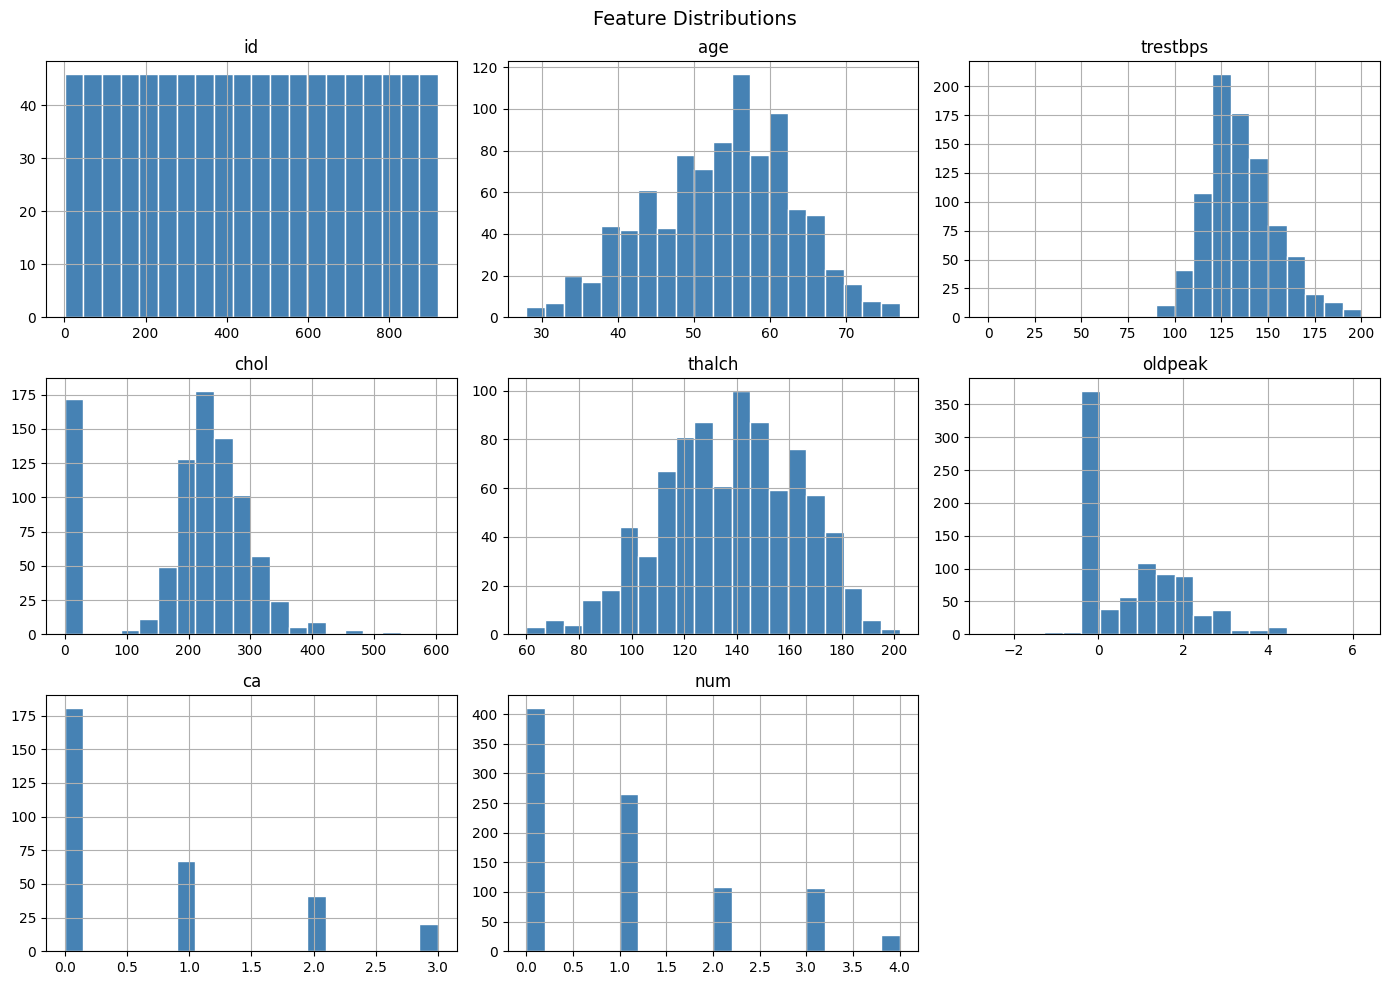

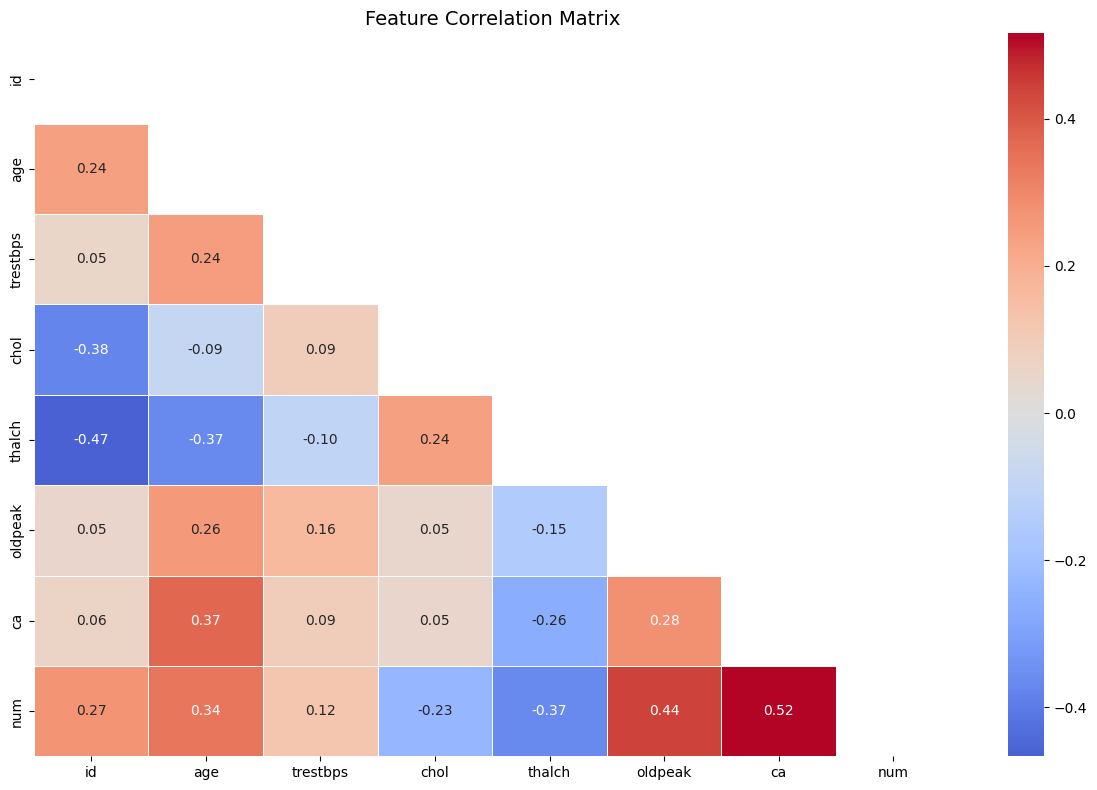


Preprocessing Completed
Train Samples : 814
Test Samples  : 184
Features      : 35


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5238 - auc: 0.6113 - loss: 0.7872 - val_accuracy: 0.7730 - val_auc: 0.8348 - val_loss: 0.5850 - learning_rate: 5.0000e-04
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7220 - auc: 0.8365 - loss: 0.5420 - val_accuracy: 0.8037 - val_auc: 0.8759 - val_loss: 0.5373 - learning_rate: 5.0000e-04
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7803 - auc: 0.8673 - loss: 0.4738 - val_accuracy: 0.8037 - val_auc: 0.8855 - val_loss: 0.5094 - learning_rate: 5.0000e-04
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7972 - auc: 0.8854 - loss: 0.4290 - val_accuracy: 0.8037 - val_auc: 0.8930 - val_loss: 0.4788 - learning_rate: 5.0000e-04
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8310 - auc: 0.8930 - loss: 0.4144 - val_accuracy: 0.7914 - val_auc: 0.8963 - val_loss: 0.4632 - learning_rate: 5.0000e-04
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 

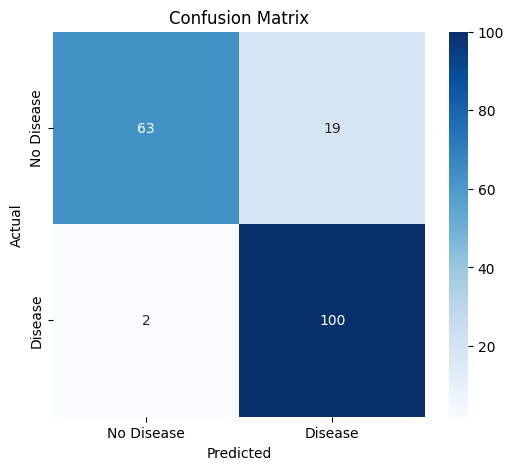

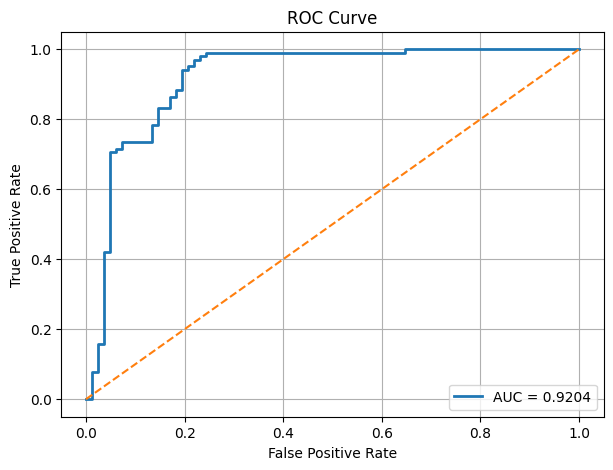


Model Saved Successfully

 HEART DISEASE PIPELINE COMPLETE 


In [22]:
# ==========================
# CELL 4 - MAIN PIPELINE
# ==========================
DATA_PATH = '/content/Heart-Disease-Predictor/heart_disease_uci.csv'
# Load Dataset
df = load_data(DATA_PATH)

# Perform EDA
perform_eda(df)

# Preprocess Dataset
(
    X_train_scaled,
    X_test_scaled,
    y_train_resampled,
    y_test,
    scaler,
    feature_columns
) = preprocess_data(df)

# Build Model
model = build_model(
    X_train_scaled.shape[1]
)

# Train Model
history = train_model(
    model,
    X_train_scaled,
    y_train_resampled
)

# Evaluate Model
evaluate_model(
    model,
    X_test_scaled,
    y_test
)

# Save Model
save_model(
    model,
    scaler,
    feature_columns
)

print("\n================================")
print(" HEART DISEASE PIPELINE COMPLETE ")
print("================================")

In [27]:

# ==========================
# CELL 5 - GUI PREDICTION
# ==========================

from tensorflow.keras.models import load_model
import joblib
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# --------------------------
# LOAD SAVED FILES
# --------------------------

model = load_model(
    '/content/Heart-Disease-Predictor/heart_disease_model.keras'
)

scaler = joblib.load(
    '/content/Heart-Disease-Predictor/heart_scaler.pkl'
)

feature_columns = joblib.load(
    '/content/Heart-Disease-Predictor/heart_features.pkl'
)

# --------------------------
# STYLING
# --------------------------

display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Serif+Display&family=DM+Mono:wght@400;500&display=swap');

.widget-label {
    font-family: 'DM Mono', monospace !important;
    font-size: 11px !important;
    color: #8a9bb0 !important;
    text-transform: uppercase;
    letter-spacing: 1px;
}

.card {
    background: #0d1117;
    border: 1px solid #21262d;
    border-radius: 12px;
    padding: 28px 32px;
    max-width: 720px;
    margin: 16px auto;
}

.title {
    font-family: 'DM Serif Display', serif;
    font-size: 26px;
    color: #e6edf3;
    margin-bottom: 4px;
}

.subtitle {
    font-family: 'DM Mono', monospace;
    font-size: 12px;
    color: #8a9bb0;
    margin-bottom: 10px;
    letter-spacing: 1px;
}

.result-box {
    border-radius: 10px;
    padding: 20px 24px;
    margin-top: 20px;
    font-family: 'DM Mono', monospace;
}

.result-positive {
    background: #2d1b1b;
    border: 1px solid #f85149;
    color: #f85149;
}

.result-negative {
    background: #1b2d1e;
    border: 1px solid #3fb950;
    color: #3fb950;
}

.result-title {
    font-size: 16px;
    font-weight: 500;
    margin-bottom: 6px;
}

.result-prob {
    font-size: 12px;
    opacity: 0.9;
}

.widget-button button {
    background: #238636 !important;
    color: white !important;
    border-radius: 8px !important;
    border: none !important;
    font-family: 'DM Mono', monospace !important;
    font-size: 13px !important;
    padding: 8px 24px !important;
}
</style>

<div class="card">
    <div class="title">Heart Disease Predictor</div>
    <div class="subtitle">
        CLINICAL RISK ASSESSMENT · DEEP LEARNING MODEL
    </div>
</div>
"""))

# --------------------------
# INPUTS
# --------------------------

style = {'description_width': '160px'}
layout = widgets.Layout(width='340px')

age = widgets.IntSlider(
    value=50,
    min=1,
    max=100,
    description='Age',
    style=style,
    layout=layout
)

sex = widgets.Dropdown(
    options=['Male','Female'],
    description='Sex',
    style=style,
    layout=layout
)

dataset = widgets.Dropdown(
    options=[
        'Cleveland',
        'Hungary',
        'Switzerland',
        'VA Long Beach'
    ],
    description='Dataset',
    style=style,
    layout=layout
)

cp = widgets.Dropdown(
    options=[
        'typical angina',
        'atypical angina',
        'non-anginal',
        'asymptomatic'
    ],
    description='Chest Pain',
    style=style,
    layout=layout
)

trestbps = widgets.IntSlider(
    value=120,
    min=80,
    max=220,
    description='Resting BP',
    style=style,
    layout=layout
)

chol = widgets.IntSlider(
    value=200,
    min=100,
    max=600,
    description='Cholesterol',
    style=style,
    layout=layout
)

fbs = widgets.Dropdown(
    options=['True','False'],
    description='Fasting BS > 120',
    style=style,
    layout=layout
)

restecg = widgets.Dropdown(
    options=[
        'normal',
        'st-t abnormality',
        'lv hypertrophy'
    ],
    description='Rest ECG',
    style=style,
    layout=layout
)

thalch = widgets.IntSlider(
    value=150,
    min=60,
    max=220,
    description='Max Heart Rate',
    style=style,
    layout=layout
)

exang = widgets.Dropdown(
    options=['True','False'],
    description='Exercise Angina',
    style=style,
    layout=layout
)

oldpeak = widgets.FloatSlider(
    value=1.0,
    min=0,
    max=7,
    step=0.1,
    description='Old Peak',
    style=style,
    layout=layout
)

slope = widgets.Dropdown(
    options=[
        'upsloping',
        'flat',
        'downsloping'
    ],
    description='Slope',
    style=style,
    layout=layout
)

ca = widgets.FloatSlider(
    value=0,
    min=0,
    max=4,
    step=1,
    description='Major Vessels (ca)',
    style=style,
    layout=layout
)

thal = widgets.Dropdown(
    options=[
        'normal',
        'fixed defect',
        'reversable defect'
    ],
    description='Thal',
    style=style,
    layout=layout
)

btn = widgets.Button(
    description='Run Prediction'
)

btn.add_class('widget-button')

output = widgets.Output()

# --------------------------
# LAYOUT
# --------------------------

left = widgets.VBox([
    age,
    sex,
    dataset,
    cp,
    trestbps,
    chol,
    fbs
])

right = widgets.VBox([
    restecg,
    thalch,
    exang,
    oldpeak,
    slope,
    ca,
    thal
])

display(
    widgets.VBox([
        widgets.HBox(
            [left, right],
            layout=widgets.Layout(gap='32px')
        ),
        btn,
        output
    ],
    layout=widgets.Layout(
        align_items='center'
    ))
)

# --------------------------
# PREDICTION
# --------------------------

def predict(b):

    output.clear_output()

    patient = pd.DataFrame({

        'id':[999],
        'age':[age.value],
        'sex':[sex.value],
        'dataset':[dataset.value],
        'cp':[cp.value],
        'trestbps':[float(trestbps.value)],
        'chol':[float(chol.value)],
        'fbs':[fbs.value],
        'restecg':[restecg.value],
        'thalch':[float(thalch.value)],
        'exang':[exang.value],
        'oldpeak':[float(oldpeak.value)],
        'slope':[slope.value],
        'ca':[float(ca.value)],
        'thal':[thal.value]

    })

    patient_encoded = pd.get_dummies(patient)

    patient_encoded = patient_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    patient_scaled = scaler.transform(
        patient_encoded
    )

    probability = model.predict(
        patient_scaled,
        verbose=0
    )[0][0]

    result_class = (
        'result-positive'
        if probability > 0.5
        else 'result-negative'
    )

    result_text = (
        '⚠ HIGH RISK OF HEART DISEASE'
        if probability > 0.5
        else '✓ LOW RISK OF HEART DISEASE'
    )

    confidence = (
        probability * 100
        if probability > 0.5
        else (1 - probability) * 100
    )

    with output:

        display(HTML(f'''
        <div class="result-box {result_class}">
            <div class="result-title">
                {result_text}
            </div>

            <div class="result-prob">
                Confidence Score: {confidence:.2f}%<br>
                Risk Probability: {probability:.4f}
            </div>
        </div>
        '''))

btn.on_click(predict)
